### Adriana Ale Huesca - A01022013
### Margarita Ojeda Hernández - A01797688
### Omar Jacobo Tueme Márquez - A00959999


In [169]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, log_loss, precision_recall_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [170]:
url = 'https://raw.githubusercontent.com/omar-tueme/ciencia-de-datos-avanzada-mek-enero-2026/main/datos_info/df_final_10_a_11.csv'
df_dinal_10_a_11 = pd.read_csv(url)

In [171]:
url = 'https://raw.githubusercontent.com/omar-tueme/ciencia-de-datos-avanzada-mek-enero-2026/main/datos_info/df_final_12mas_hombre.csv'
df_final_12mas_hombre = pd.read_csv(url)

In [172]:
url = 'https://raw.githubusercontent.com/omar-tueme/ciencia-de-datos-avanzada-mek-enero-2026/main/datos_info/df_final_12mas_mujer.csv'
df_final_12mas_mujer = pd.read_csv(url)

In [173]:
df_dinal_10_a_11 = df_dinal_10_a_11.drop('Edad', axis=1)


df_dinal_10_a_11.head()

,Dificultad para aprender,Es mujer,Alcohol,Ansiedad,Depresión,Dificultad de concentración,Dormir mal,Pensamiento suicida,Desordenes alimenticios,Accidente,Robo Agresión o Violencia
0,0.0,1.0,0.0,0.50,0.67,0.00,0.00,0.0,0.33,0.0,0.0
1,0.0,1.0,0.0,0.00,0.25,0.00,1.00,0.0,0.33,0.0,0.0
2,1.0,1.0,0.0,0.75,0.67,0.67,0.00,0.0,0.67,0.0,0.0
3,0.0,1.0,0.0,0.75,1.00,0.33,0.33,1.0,1.00,0.0,0.0
4,0.0,1.0,0.0,0.25,0.25,0.00,0.00,0.0,0.33,0.0,0.0


In [174]:
df_final_12mas_hombre = df_final_12mas_hombre.drop('Edad', axis=1)

df_final_12mas_hombre.head()

,Dificultad para aprender,Fuma,Alcohol,Opiáceos,Tranquilizantes,Drogas ilícitas,Hipertensión,Colesterol,Triglicéridos,Ansiedad,Depresión,Dificultad de concentración,Dormir mal,Pensamiento suicida,Desordenes alimenticios,Accidente,Robo Agresión o Violencia,Acoso Sexual
0,0.0,0.0,0.75,0.0,0.0,0.0,0.0,0.0,0.0,0.25,0.25,0.00,1.00,0.25,0.33,0.0,0.0,0.0
1,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.33,0.33,0.00,0.33,0.0,0.0,0.0
2,1.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,1.00,0.33,0.00,0.00,0.00,0.33,0.0,0.0,0.0
3,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.25,0.33,0.33,0.33,0.00,0.33,0.0,0.0,0.0
4,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.75,0.25,0.67,0.00,0.00,0.33,0.0,0.0,0.0


In [175]:
df_final_12mas_mujer = df_final_12mas_mujer.drop('Edad', axis=1)

df_final_12mas_mujer.head()

,Dificultad para aprender,Fuma,Alcohol,Tranquilizantes,Drogas ilícitas,Hipertensión,Colesterol,Triglicéridos,Embarazo,Ansiedad,Depresión,Dificultad de concentración,Dormir mal,Pensamiento suicida,Desordenes alimenticios,Accidente,Robo Agresión o Violencia,Acoso Sexual
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.25,1.00,0.67,0.00,0.00,0.67,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.75,0.25,0.00,0.00,0.00,0.00,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.75,0.67,0.00,0.33,0.00,0.00,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0
4,1.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.25,0.50,0.67,0.00,0.25,0.67,0.0,0.0,0.0


# 5. Modelos y Algortimos

Algoritmos
* Regresión logística
* Árbol de decisión
* KNN

Métodos de ensamble
* Random forest
* Gradient boosting


### Definiendo funciones que se van a repetir

In [176]:
from ast import Str
def tree_depth(X, y):
  '''
  Determinar la profunidad del arbol óptima utilizando cross validation

  Parametros
  ------------
  X : Predictores
  y : Variable objetivo

  Regresa
  ------------
  Gráfica con métricas de evaluación para decidir cual es la profundidad del
  arbol óptima
  '''

  depths = range(1,11)
  test_scores = []
  precision_scores = []
  recall_scores = []
  f1_scores = []
  auc_scores = []

  cv = StratifiedKFold(n_splits=5)

  for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, class_weight='balanced')
    score = cross_val_score(clf, X, y, cv=cv)
    score_precision = cross_val_score(clf, X, y, cv=cv, scoring='precision')
    score_recall = cross_val_score(clf, X, y, cv=cv, scoring='recall')
    score_f1 = cross_val_score(clf, X, y, cv=cv, scoring='f1')
    score_auc = cross_val_score(clf, X, y, cv=cv, scoring='roc_auc')
    test_scores.append(score.mean())
    precision_scores.append(score_precision.mean())
    recall_scores.append(score_recall.mean())
    f1_scores.append(score_f1.mean())
    auc_scores.append(score_auc.mean())

  plt.plot(depths, test_scores, marker='o', label='Accuracy')
  plt.plot(depths, precision_scores, marker='o', label='Precision')
  plt.plot(depths, recall_scores, marker='o', label='Recall')
  plt.plot(depths, f1_scores, marker='o', label='F1')
  plt.plot(depths, auc_scores, marker='o', label='AUC')

  plt.xlabel('Max Depth')
  plt.ylabel('Score')
  plt.legend()
  plt.grid(True)
  plt.show()

# ==============================================================================
# ==============================================================================
# ==============================================================================

def knn_vecinos(X, y):
  '''
  Determinar la cantidad de vecinos KNN óptima utilizando cross validation

  Parametros
  ------------
  X : Predictores
  y : Variable objetivo

  Regresa
  ------------
  Gráfica con métricas de evaluación para decidir cual es la cantidad de vecinos
  KNN óptima
  '''
  k_values = range(1, 51, 2)
  test_scores = []
  precision_scores = []
  recall_scores = []
  f1_scores = []
  auc_scores = []

  cv = StratifiedKFold(n_splits=5)

  for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k, weights='distance')
    score = cross_val_score(clf, X, y, cv=cv)
    score_precision = cross_val_score(clf, X, y, cv=cv, scoring='precision')
    score_recall = cross_val_score(clf, X, y, cv=cv, scoring='recall')
    score_f1 = cross_val_score(clf, X, y, cv=cv, scoring='f1')
    score_auc = cross_val_score(clf, X, y, cv=cv, scoring='roc_auc')
    test_scores.append(score.mean())
    precision_scores.append(score_precision.mean())
    recall_scores.append(score_recall.mean())
    f1_scores.append(score_f1.mean())
    auc_scores.append(score_auc.mean())

  plt.plot(k_values, test_scores, marker='o', label='Accuracy')
  plt.plot(k_values, precision_scores, marker='o', label='Precision')
  plt.plot(k_values, recall_scores, marker='o', label='Recall')
  plt.plot(k_values, f1_scores, marker='o', label='F1')
  plt.plot(k_values, auc_scores, marker='o', label='AUC')

  plt.xlabel('Num. K Neighbours')
  plt.ylabel('Score')
  plt.legend()
  plt.grid(True)
  plt.show()

# ==============================================================================
# ==============================================================================
# ==============================================================================

def cv_todos_los_modelos(X, y, tree_depth, num_neighbours, random, num_estimators, lr_iter):
  '''
  Obtener métricas de evaluación para todos los modelos que se utilizaran pero
  con metodología de validación cruzada

  Parametros
  ------------
  X : Predictores
  y : Variable objetivo
  tree_depth : Profundidad del arbol de decisión
  num_neighbours : Cantidad de vecinos KNN
  random : Semilla
  num_estimators : Cantidad de arboles en el Random Forest y el Gradient Boosting
  lr_iter : Cantidad de iteraciones para la Regresión Logística

  Regresa
  ------------
  Tabla comparando las métricas de evaluación de cada modelo con validación
  cruzada
  '''

  neg = (y == 0).sum()
  pos = (y == 1).sum()
  scale_pos_weight = neg / pos

  cv = StratifiedKFold(n_splits=5)

  scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

  clf_tree = DecisionTreeClassifier(max_depth=tree_depth, random_state=random, class_weight='balanced')
  tree_scores = cross_validate(clf_tree, X, y, cv=cv, scoring=scoring)

  knn = KNeighborsClassifier(n_neighbors=num_neighbours, weights='distance')
  knn_scores = cross_validate(knn, X, y, cv=cv, scoring=scoring)

  lr = LogisticRegression(max_iter=lr_iter, random_state=random, class_weight='balanced')
  lr_scores = cross_validate(lr, X, y, cv=cv, scoring=scoring)

  rf = RandomForestClassifier(n_estimators=num_estimators, max_depth=tree_depth, random_state=random, class_weight='balanced')
  rf_scores = cross_validate(rf, X, y, cv=cv, scoring=scoring)

  gbt = XGBClassifier(
    n_estimators=num_estimators,
    max_depth=tree_depth,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=1,
    reg_lambda=3,
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    random_state=random,
    scale_pos_weight=scale_pos_weight
  )
  gbt_scores = cross_validate(gbt, X, y, cv=cv, scoring=scoring)

  comparison = pd.DataFrame({
      'Decision Tree': [
          tree_scores['test_accuracy'].mean(),
          tree_scores['test_precision'].mean(),
          tree_scores['test_recall'].mean(),
          tree_scores['test_f1'].mean(),
          tree_scores['test_roc_auc'].mean(),
      ],
      'KNN': [
          knn_scores['test_accuracy'].mean(),
          knn_scores['test_precision'].mean(),
          knn_scores['test_recall'].mean(),
          knn_scores['test_f1'].mean(),
          knn_scores['test_roc_auc'].mean(),
      ],
      'Logistic Regression': [
          lr_scores['test_accuracy'].mean(),
          lr_scores['test_precision'].mean(),
          lr_scores['test_recall'].mean(),
          lr_scores['test_f1'].mean(),
          lr_scores['test_roc_auc'].mean(),
      ],
      'Random Forest': [
          rf_scores['test_accuracy'].mean(),
          rf_scores['test_precision'].mean(),
          rf_scores['test_recall'].mean(),
          rf_scores['test_f1'].mean(),
          rf_scores['test_roc_auc'].mean(),
      ],
      'XGBoost': [
          gbt_scores['test_accuracy'].mean(),
          gbt_scores['test_precision'].mean(),
          gbt_scores['test_recall'].mean(),
          gbt_scores['test_f1'].mean(),
          gbt_scores['test_roc_auc'].mean(),
      ],
  }, index=['Accuracy (CV)', 'Precision (CV)', 'Recall (CV)', 'F1 (CV)', 'AUC (CV)'])

  return comparison

# ==============================================================================
# ==============================================================================
# ==============================================================================

def cv_todos_los_modelos_smote(X, y, tree_depth, num_neighbours, random, num_estimators, lr_iter):
  '''
  Obtener métricas de evaluación para todos los modelos que se utilizaran pero
  con metodología de validación cruzada. Utilizando SMOTE en vez de
  class_weight='balanced' & weights='distance' & scale_pos_weight=neg/pos

  Parametros
  ------------
  X : Predictores
  y : Variable objetivo
  tree_depth : Profundidad del arbol de decisión
  num_neighbours : Cantidad de vecinos KNN
  random : Semilla
  num_estimators : Cantidad de arboles en el Random Forest y el Gradient Boosting
  lr_iter : Cantidad de iteraciones para la Regresión Logística

  Regresa
  ------------
  Tabla comparando las métricas de evaluación de cada modelo con validación
  cruzada
  '''

  neg = (y == 0).sum()
  pos = (y == 1).sum()
  scale_pos_weight = neg / pos

  cv = StratifiedKFold(n_splits=5)

  scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

  pipeline_clf_tree = Pipeline([
    ('smote', SMOTE(random_state=random)),
    ('clf', DecisionTreeClassifier(max_depth=tree_depth, random_state=random))
  ])
  tree_scores = cross_validate(pipeline_clf_tree, X, y, cv=cv, scoring=scoring)

  pipeline_knn = Pipeline([
    ('smote', SMOTE(random_state=random)),
    ('clf', KNeighborsClassifier(n_neighbors=num_neighbours))
  ])
  knn_scores = cross_validate(pipeline_knn, X, y, cv=cv, scoring=scoring)

  pipeline_lr = Pipeline([
    ('smote', SMOTE(random_state=random)),
    ('clf', LogisticRegression(max_iter=lr_iter, random_state=random))
  ])
  lr_scores = cross_validate(pipeline_lr, X, y, cv=cv, scoring=scoring)

  pipeline_rf = Pipeline([
    ('smote', SMOTE(random_state=random)),
    ('clf', RandomForestClassifier(n_estimators=num_estimators, max_depth=tree_depth, random_state=random))
  ])
  rf_scores = cross_validate(pipeline_rf, X, y, cv=cv, scoring=scoring)

  pipeline_gbt = Pipeline([
    ('smote', SMOTE(random_state=random)),
    ('clf', XGBClassifier(
        n_estimators=num_estimators,
        max_depth=tree_depth,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=1,
        reg_lambda=3,
        objective='binary:logistic',
        eval_metric='auc',
        tree_method='hist',
        random_state=random))
  ])
  gbt_scores = cross_validate(pipeline_gbt, X, y, cv=cv, scoring=scoring)

  comparison = pd.DataFrame({
      'Decision Tree': [
          tree_scores['test_accuracy'].mean(),
          tree_scores['test_precision'].mean(),
          tree_scores['test_recall'].mean(),
          tree_scores['test_f1'].mean(),
          tree_scores['test_roc_auc'].mean(),
      ],
      'KNN': [
          knn_scores['test_accuracy'].mean(),
          knn_scores['test_precision'].mean(),
          knn_scores['test_recall'].mean(),
          knn_scores['test_f1'].mean(),
          knn_scores['test_roc_auc'].mean(),
      ],
      'Logistic Regression': [
          lr_scores['test_accuracy'].mean(),
          lr_scores['test_precision'].mean(),
          lr_scores['test_recall'].mean(),
          lr_scores['test_f1'].mean(),
          lr_scores['test_roc_auc'].mean(),
      ],
      'Random Forest': [
          rf_scores['test_accuracy'].mean(),
          rf_scores['test_precision'].mean(),
          rf_scores['test_recall'].mean(),
          rf_scores['test_f1'].mean(),
          rf_scores['test_roc_auc'].mean(),
      ],
      'XGBoost': [
          gbt_scores['test_accuracy'].mean(),
          gbt_scores['test_precision'].mean(),
          gbt_scores['test_recall'].mean(),
          gbt_scores['test_f1'].mean(),
          gbt_scores['test_roc_auc'].mean(),
      ],
  }, index=['Accuracy (CV)', 'Precision (CV)', 'Recall (CV)', 'F1 (CV)', 'AUC (CV)'])

  return comparison

# ==============================================================================
# ==============================================================================
# ==============================================================================

def train_test_tree(X_train, X_test, y_train, y_test, tree_depth, random, feature_names):
  '''
  Train - test para el árbol de decisión. El threshold del árbol se hará en
  aquel punto que optimiza F1 dado el desbalance de clases

  Parametros
  ------------
  X_train : Submuestra de predictores para entrenar
  X_test : Submuestra de predictores para validar
  y_train : Submuestra de objetivo para entrenar
  y_test : Submuestra de objetivo para validar
  tree_depth : Profundidad del arbol de decisión
  random : Semilla
  feature_names : Nombres de los predictores

  Regresa
  ------------
  Arbol de decisión, relevancia de features y métricas de evaluación
  '''

  clf_tree = DecisionTreeClassifier(max_depth=tree_depth, random_state=random, class_weight='balanced')
  clf_tree.fit(X_train, y_train)

  tree_proba = clf_tree.predict_proba(X_test)[:, 1]
  tree_precision, tree_recall, tree_thresholds = precision_recall_curve(y_test, tree_proba)
  tree_f1_scores = 2 * (tree_precision * tree_recall) / (tree_precision + tree_recall + 1e-8)
  tree_best_idx = np.argmax(tree_f1_scores)
  tree_best_threshold = tree_thresholds[tree_best_idx]
  tree_pred = (tree_proba >= tree_best_threshold).astype(int)

  report_tree = classification_report(y_test, tree_pred)
  auc_tree = roc_auc_score(y_test, tree_proba)

  print(report_tree)
  print(f'El valor AUC del árbol que optimiza F1 es = {auc_tree:.4f}')

  plt.figure(figsize=(30, 10))

  tree.plot_tree(clf_tree,
               feature_names=feature_names,
               class_names=y_train.astype(str).unique(),
               filled=True)

  plt.show()

  tree_importances = pd.Series(clf_tree.feature_importances_, index=feature_names).sort_values()

  plt.figure(figsize=(5, 4))

  tree_importances.plot(kind='barh')

  plt.tight_layout()
  plt.title('Tree Feature Importance')
  plt.show()

# ==============================================================================
# ==============================================================================
# ==============================================================================

def train_test_knn(X_train, X_test, y_train, y_test, num_neighbours, feature_names):
  '''
  Train - test para KNN. El threshold del KNN se hará en aquel punto que
  optimiza F1 dado el desbalance de clases

  Parametros
  ------------
  X_train : Submuestra de predictores para entrenar
  X_test : Submuestra de predictores para validar
  y_train : Submuestra de objetivo para entrenar
  y_test : Submuestra de objetivo para validar
  num_neighbours : Cantidad de vecinos KNN
  feature_names : Nombres de los predictores

  Regresa
  ------------
  Métricas de evaluación del KNN
  '''

  knn = KNeighborsClassifier(n_neighbors=num_neighbours, weights='distance')
  knn.fit(X_train, y_train)

  knn_proba = knn.predict_proba(X_test)[:, 1]
  knn_precision, knn_recall, knn_thresholds = precision_recall_curve(y_test, knn_proba)
  knn_f1_scores = 2 * (knn_precision * knn_recall) / (knn_precision + knn_recall + 1e-8)
  knn_best_idx = np.argmax(knn_f1_scores)
  knn_best_threshold = knn_thresholds[knn_best_idx]
  knn_pred = (knn_proba >= knn_best_threshold).astype(int)

  report_knn = classification_report(y_test, knn_pred)
  auc_knn = roc_auc_score(y_test, knn_proba)

  print(report_knn)
  print(f'El valor AUC de KNN que optimiza F1 es = {auc_knn:.4f}')

# ==============================================================================
# ==============================================================================
# ==============================================================================

def train_test_lr(X_train, X_test, y_train, y_test, lr_iter, random, feature_names):
  '''
  Train - test para la regresión logística. El threshold de la regresión
  logística se hará en aquel punto que optimiza F1 dado el desbalance de clases

  Parametros
  ------------
  X_train : Submuestra de predictores para entrenar
  X_test : Submuestra de predictores para validar
  y_train : Submuestra de objetivo para entrenar
  y_test : Submuestra de objetivo para validar
  lr_iter : Cantidad de iteraciones para la Regresión Logística
  random : Semilla
  feature_names : Nombres de los predictores

  Regresa
  ------------
  Relevancia de features y métricas de evaluación de la regresión logística
  '''

  lr = LogisticRegression(max_iter=lr_iter, random_state=random, class_weight='balanced')
  lr.fit(X_train, y_train)

  lr_proba = lr.predict_proba(X_test)[:, 1]
  lr_precision, lr_recall, lr_thresholds = precision_recall_curve(y_test, lr_proba)
  lr_f1_scores = 2 * (lr_precision * lr_recall) / (lr_precision + lr_recall + 1e-8)
  lr_best_idx = np.argmax(lr_f1_scores)
  lr_best_threshold = lr_thresholds[lr_best_idx]
  lr_pred = (lr_proba >= lr_best_threshold).astype(int)

  report_lr = classification_report(y_test, lr_pred)
  auc_lr = roc_auc_score(y_test, lr_proba)

  print(report_lr)
  print(f'El valor AUC de LR que optimiza F1 es = {auc_lr:.4f}')

  lr_importances = pd.Series(lr.coef_.ravel(), index=feature_names).sort_values()

  plt.figure(figsize=(5, 4))

  lr_importances.plot(kind='barh')

  plt.tight_layout()
  plt.title('LR Feature Coefficients')
  plt.show()

# ==============================================================================
# ==============================================================================
# ==============================================================================

def train_test_rm(X_train, X_test, y_train, y_test, tree_depth, num_estimators, random, feature_names):
  '''
  Train - test para el random forest. El threshold del random forest se hará en
  aquel punto que optimiza F1 dado el desbalance de clases

  Parametros
  ------------
  X_train : Submuestra de predictores para entrenar
  X_test : Submuestra de predictores para validar
  y_train : Submuestra de objetivo para entrenar
  y_test : Submuestra de objetivo para validar
  tree_depth : Profundidad del arbol de decisión
  num_estimators : Cantidad de arboles en el Random Forest y el Gradient Boosting
  random : Semilla
  feature_names : Nombres de los predictores

  Regresa
  ------------
  Relevancia de features y métricas de evaluación del random forest
  '''

  rf = RandomForestClassifier(n_estimators=num_estimators, max_depth=tree_depth, random_state=random, class_weight='balanced')
  rf.fit(X_train, y_train)

  rf_proba = rf.predict_proba(X_test)[:, 1]
  rf_precision, rf_recall, rf_thresholds = precision_recall_curve(y_test, rf_proba)
  rf_f1_scores = 2 * (rf_precision * rf_recall) / (rf_precision + rf_recall + 1e-8)
  rf_best_idx = np.argmax(rf_f1_scores)
  rf_best_threshold = rf_thresholds[rf_best_idx]
  rf_pred = (rf_proba >= rf_best_threshold).astype(int)

  report_rf = classification_report(y_test, rf_pred)
  auc_rf = roc_auc_score(y_test, rf_proba)

  print(report_rf)
  print(f'El valor AUC de RF que optimiza F1 es = {auc_rf:.4f}')

  rf_importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values()

  plt.figure(figsize=(5, 4))

  rf_importances.plot(kind='barh')

  plt.tight_layout()
  plt.title('Random Forest Feature Importance')
  plt.show()


# ==============================================================================
# ==============================================================================
# ==============================================================================

def train_test_gbt(X_train, X_test, y_train, y_test, tree_depth, num_estimators, random, feature_names):
  '''
  Train - test para el gradient boosting. El threshold del gradient boosting se
  hará en aquel punto que optimiza F1 dado el desbalance de clases

  Parametros
  ------------
  X_train : Submuestra de predictores para entrenar
  X_test : Submuestra de predictores para validar
  y_train : Submuestra de objetivo para entrenar
  y_test : Submuestra de objetivo para validar
  tree_depth : Profundidad del arbol de decisión
  num_estimators : Cantidad de arboles en el Random Forest y el Gradient Boosting
  random : Semilla
  feature_names : Nombres de los predictores

  Regresa
  ------------
  Relevancia de features y métricas de evaluación del gradient boosting
  '''

  neg = (y_train == 0).sum()
  pos = (y_train == 1).sum()
  scale_pos_weight = neg / pos

  gbt = XGBClassifier(
    n_estimators=num_estimators,
    max_depth=tree_depth,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=1,
    reg_lambda=3,
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    random_state=random,
    scale_pos_weight=scale_pos_weight
  )
  gbt.fit(X_train, y_train)

  gbt_proba = gbt.predict_proba(X_test)[:, 1]
  gbt_precision, gbt_recall, gbt_thresholds = precision_recall_curve(y_test, gbt_proba)
  gbt_f1_scores = 2 * (gbt_precision * gbt_recall) / (gbt_precision + gbt_recall + 1e-8)
  gbt_best_idx = np.argmax(gbt_f1_scores)
  gbt_best_threshold = gbt_thresholds[gbt_best_idx]
  gbt_pred = (gbt_proba >= gbt_best_threshold).astype(int)

  report_gbt = classification_report(y_test, gbt_pred)
  auc_gbt = roc_auc_score(y_test, gbt_proba)

  print(report_gbt)
  print(f'El valor AUC de GBT que optimiza F1 es = {auc_gbt:.4f}')

  gbt_importances = pd.Series(gbt.feature_importances_, index=feature_names).sort_values()

  plt.figure(figsize=(5, 4))

  gbt_importances.plot(kind='barh')

  plt.tight_layout()
  plt.title('Gradient Boosting Feature Importance')
  plt.show()

## Niños de 10 y 11 años

Primero vamos a crear las bases de datos que vamos a utilizar. Para CV vamos a utilizar toda la base de datos ya que es validación cruzada. Para el entrenamiento de modelo vamos a utilizar una muestra de 20% para la prueba. Dado que tenemos desbalance de clases, siempre vamos a tratar de mantener la misma proporción de nuestra variable objetivo. Ésto lo logramos utilizando el parametro "stratify=y"

In [177]:
feature_names = df_dinal_10_a_11.columns.drop('Dificultad para aprender')

X = df_dinal_10_a_11[feature_names]

y = df_dinal_10_a_11['Dificultad para aprender']

In [178]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

### Selección de hyperparametros

Dado que vamos a usar árbol de decisión y KNN primero queremos asegurarnos de escoger los hyperparametros correctos. Particularmente la profundidad del arbol y la cantidad de vecinos

Empezando por el arbol, comparamos el comportamiento de varias métricas de evaluación mediantes validación cruzada. Se decide optar por una profundidad de 2 dado que Accuracy, Recall, Precision y F1 se mantienen iguales vs 1 y hay ganancia en AUC. Dada la degradación en Precision y F1 con una profundiad de 3 y la subsecuente degradación en Recall y AUC empezando con una profunidad de 4, consideramos mejor quedarnos con una profundidad de 2

Para los KN Vecinos... por desgracia perdemos Recall y F1 muy rapido (N = 5). Dado el desbalance que tenemos en la muestra, no nos gustaría comprometer mejoras margianles en AUC por perdida en Recall y F1. Es por eso que escogemos 3 vecinos. Reconocemos, sin embargo, que esto hace el modelo menos robusto

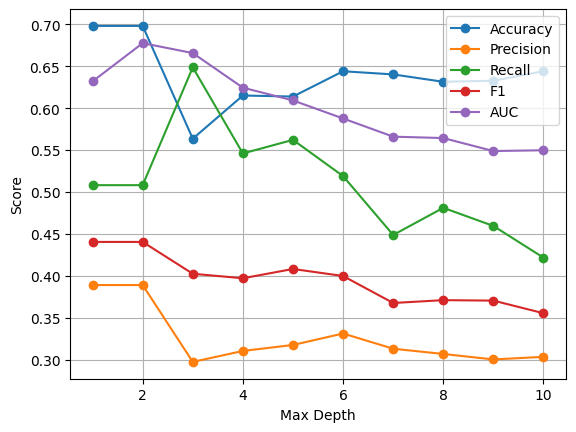

In [179]:
tree_depth(X, y)

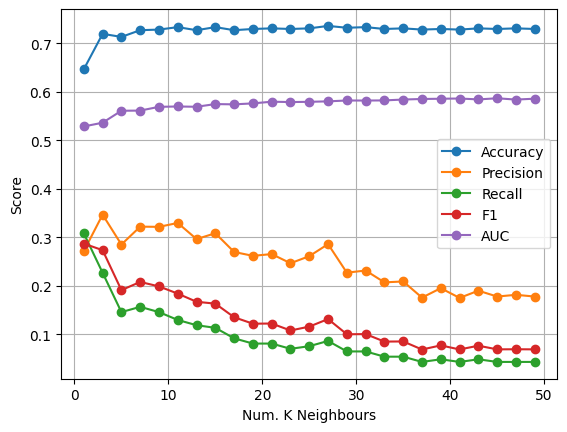

In [180]:
knn_vecinos(X, y)

### Creación de modelos - Validación cruzada

Falta interpretación
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A

In [181]:
depth = 2
neighbours = 3
seed = 1
num_estimators = 1000
lr_iter = 400


cv_todos_los_modelos(X, y, depth, neighbours, seed, num_estimators, lr_iter)

,Decision Tree,KNN,Logistic Regression,Random Forest,XGBoost
Accuracy (CV),0.698113,0.719497,0.664151,0.654088,0.645283
Precision (CV),0.388927,0.346781,0.360286,0.349001,0.334137
Recall (CV),0.508108,0.227027,0.551351,0.556757,0.502703
F1 (CV),0.440378,0.273581,0.435064,0.428575,0.398919
AUC (CV),0.677581,0.536331,0.661808,0.676119,0.604674


In [182]:
depth = 2
neighbours = 3
seed = 1
num_estimators = 1000
lr_iter = 400

cv_todos_los_modelos_smote(X, y, depth, neighbours, seed, num_estimators, lr_iter)

,Decision Tree,KNN,Logistic Regression,Random Forest,XGBoost
Accuracy (CV),0.669182,0.645283,0.642767,0.666667,0.727044
Precision (CV),0.359325,0.291969,0.331971,0.359710,0.412899
Recall (CV),0.497297,0.372973,0.524324,0.524324,0.243243
F1 (CV),0.415491,0.326457,0.405260,0.422690,0.290641
AUC (CV),0.637151,0.565064,0.652016,0.667523,0.612583


### Creación de modelos - Train / Test

Falta interpretación
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A

              precision    recall  f1-score   support

         0.0       0.86      0.74      0.79       122
         1.0       0.41      0.59      0.48        37

    accuracy                           0.70       159
   macro avg       0.63      0.67      0.64       159
weighted avg       0.75      0.70      0.72       159

El valor AUC del árbol que optimiza F1 es = 0.6769


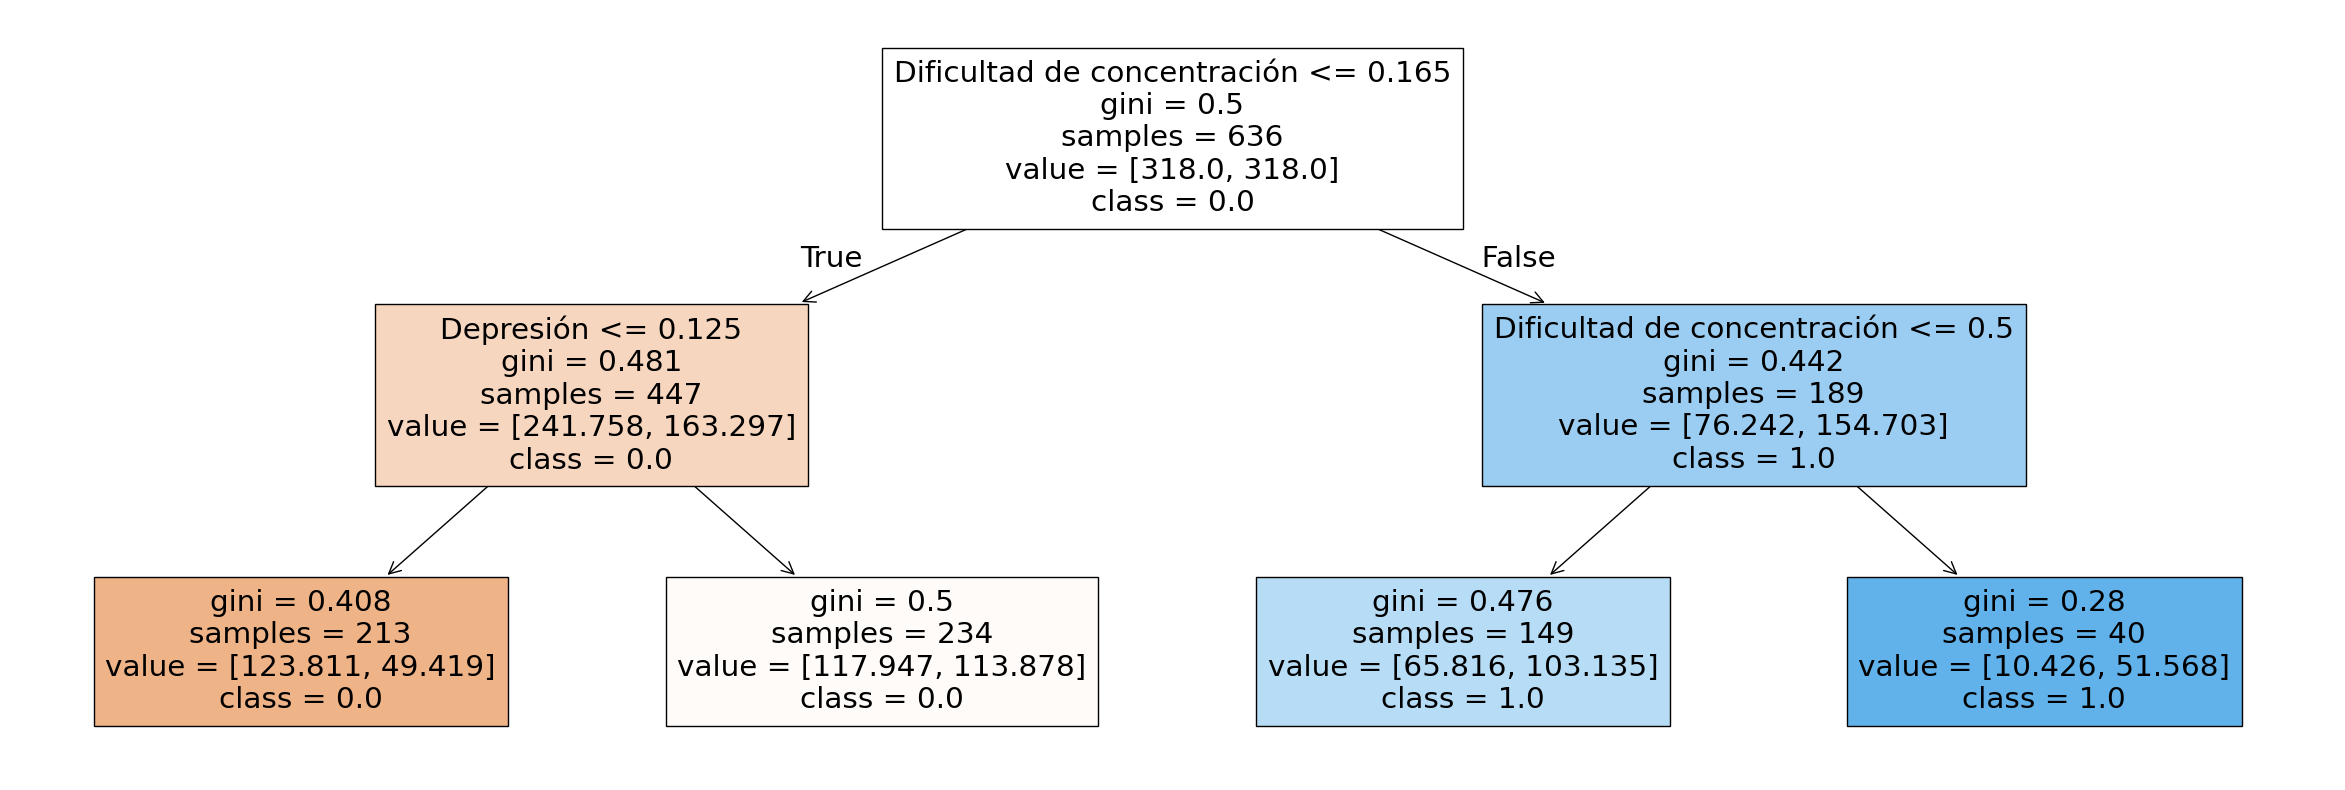

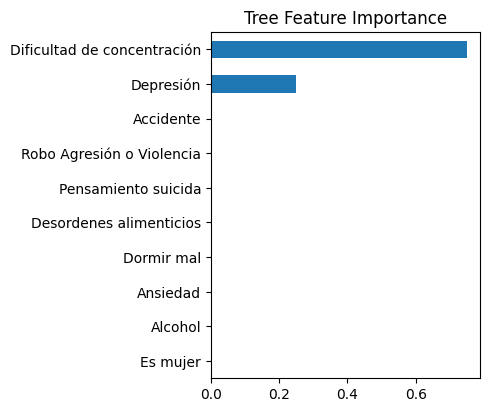

In [183]:
depth = 2
seed = 1

train_test_tree(X_train, X_test, y_train, y_test, depth, seed, feature_names)

In [184]:
neighbours = 3

train_test_knn(X_train, X_test, y_train, y_test, neighbours, feature_names)

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       122
         1.0       0.23      1.00      0.38        37

    accuracy                           0.23       159
   macro avg       0.12      0.50      0.19       159
weighted avg       0.05      0.23      0.09       159

El valor AUC de KNN que optimiza F1 es = 0.5748


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

         0.0       0.86      0.76      0.81       122
         1.0       0.43      0.59      0.50        37

    accuracy                           0.72       159
   macro avg       0.65      0.68      0.65       159
weighted avg       0.76      0.72      0.74       159

El valor AUC de LR que optimiza F1 es = 0.6693


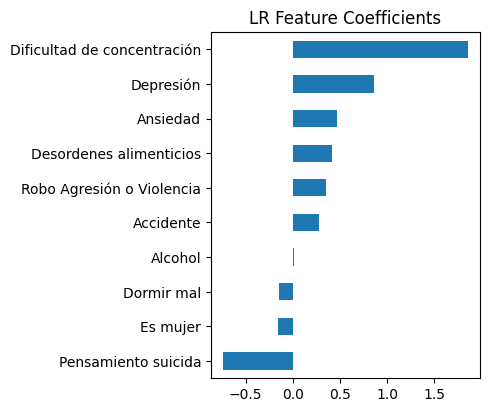

In [185]:
lr_iter = 400
seed = 1

train_test_lr(X_train, X_test, y_train, y_test, lr_iter, seed, feature_names)

              precision    recall  f1-score   support

         0.0       0.89      0.63      0.74       122
         1.0       0.38      0.73      0.50        37

    accuracy                           0.65       159
   macro avg       0.63      0.68      0.62       159
weighted avg       0.77      0.65      0.68       159

El valor AUC de RF que optimiza F1 es = 0.6646


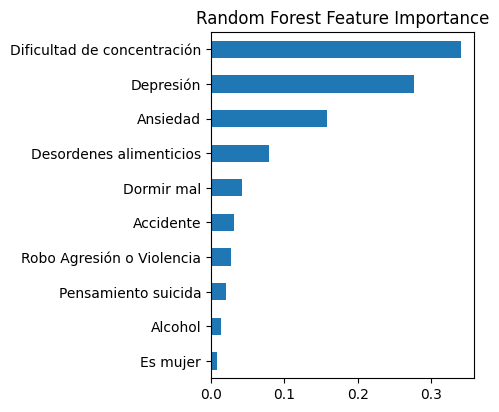

In [186]:
depth = 2
seed = 1
num_estimators = 1000

train_test_rm(X_train, X_test, y_train, y_test, depth, num_estimators, seed, feature_names)

              precision    recall  f1-score   support

         0.0       0.85      0.78      0.81       122
         1.0       0.43      0.54      0.48        37

    accuracy                           0.72       159
   macro avg       0.64      0.66      0.64       159
weighted avg       0.75      0.72      0.73       159

El valor AUC de GBT que optimiza F1 es = 0.6495


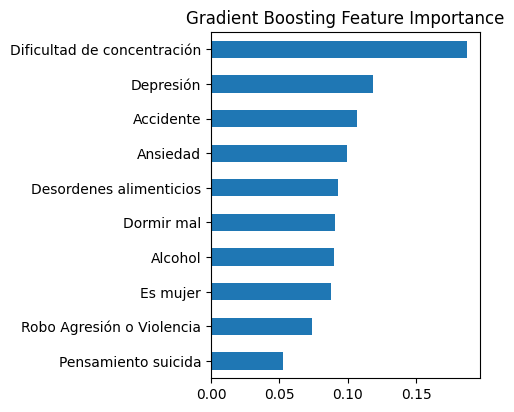

In [187]:
depth = 2
seed = 1
num_estimators = 1000

train_test_gbt(X_train, X_test, y_train, y_test, depth, num_estimators, seed, feature_names)

## Adolescentes Varones de 12 a 17 años

Primero vamos a crear las bases de datos que vamos a utilizar. Para CV vamos a utilizar toda la base de datos ya que es validación cruzada. Para el entrenamiento de modelo vamos a utilizar una muestra de 20% para la prueba. Dado que tenemos desbalance de clases, siempre vamos a tratar de mantener la misma proporción de nuestra variable objetivo. Ésto lo logramos utilizando el parametro "stratify=y"

In [188]:
feature_names = df_final_12mas_hombre.columns.drop('Dificultad para aprender')

X = df_final_12mas_hombre[feature_names]

y = df_final_12mas_hombre['Dificultad para aprender']

In [189]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

### Selección de hyperparametros

Dado que vamos a usar árbol de decisión y KNN primero queremos asegurarnos de escoger los hyperparametros correctos. Particularmente la profundidad del arbol y la cantidad de vecinos

Empezando por el arbol, obtamos por una profundidad de 4 dado que esto maximiza AUC mientras que todas las otras métricas de evaluación se mantienen muy similaes

Para los KN Vecinos se repite un patron similar al de los niños de 10 y 11 años. Nos quedaremos con 3 vecinos antes de que Recall (y F1) se deterioren más

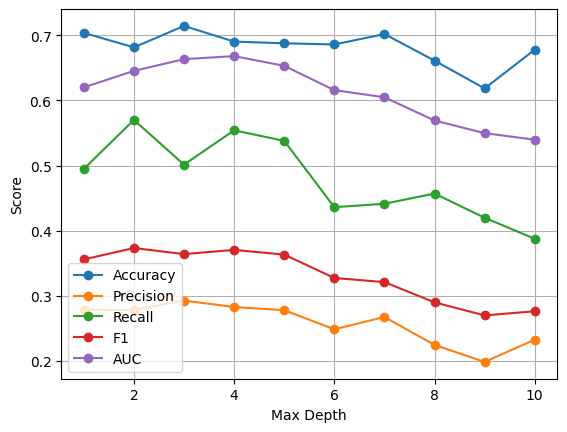

In [190]:
tree_depth(X, y)

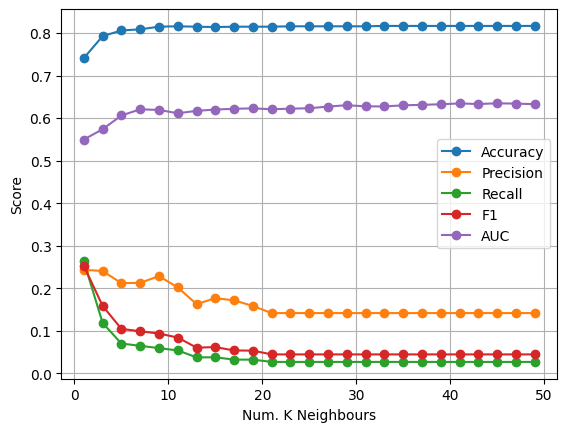

In [191]:
knn_vecinos(X, y)

### Creación de modelos - Validación cruzada

Falta interpretación
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A

In [192]:
depth = 4
neighbours = 3
seed = 1
num_estimators = 1000
lr_iter = 400


cv_todos_los_modelos(X, y, depth, neighbours, seed, num_estimators, lr_iter)

,Decision Tree,KNN,Logistic Regression,Random Forest,XGBoost
Accuracy (CV),0.690325,0.792702,0.682345,0.709937,0.694813
Precision (CV),0.284028,0.240609,0.265591,0.288224,0.251529
Recall (CV),0.554054,0.118492,0.516074,0.510811,0.419630
F1 (CV),0.374141,0.158618,0.349718,0.368104,0.313331
AUC (CV),0.673289,0.573891,0.647874,0.674345,0.618767


In [193]:
depth = 4
neighbours = 3
seed = 1
num_estimators = 1000
lr_iter = 400

cv_todos_los_modelos_smote(X, y, depth, neighbours, seed, num_estimators, lr_iter)

,Decision Tree,KNN,Logistic Regression,Random Forest,XGBoost
Accuracy (CV),0.753563,0.706381,0.674333,0.721488,0.798044
Precision (CV),0.315325,0.248602,0.259787,0.287586,0.307665
Recall (CV),0.360740,0.381366,0.521622,0.457041,0.150640
F1 (CV),0.328992,0.300512,0.345667,0.352588,0.198926
AUC (CV),0.626433,0.583587,0.633711,0.672547,0.612781


### Creación de modelos - Train / Test

Falta interpretación
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A

              precision    recall  f1-score   support

         0.0       0.87      0.73      0.80       188
         1.0       0.25      0.46      0.33        37

    accuracy                           0.69       225
   macro avg       0.56      0.60      0.56       225
weighted avg       0.77      0.69      0.72       225

El valor AUC del árbol que optimiza F1 es = 0.6061


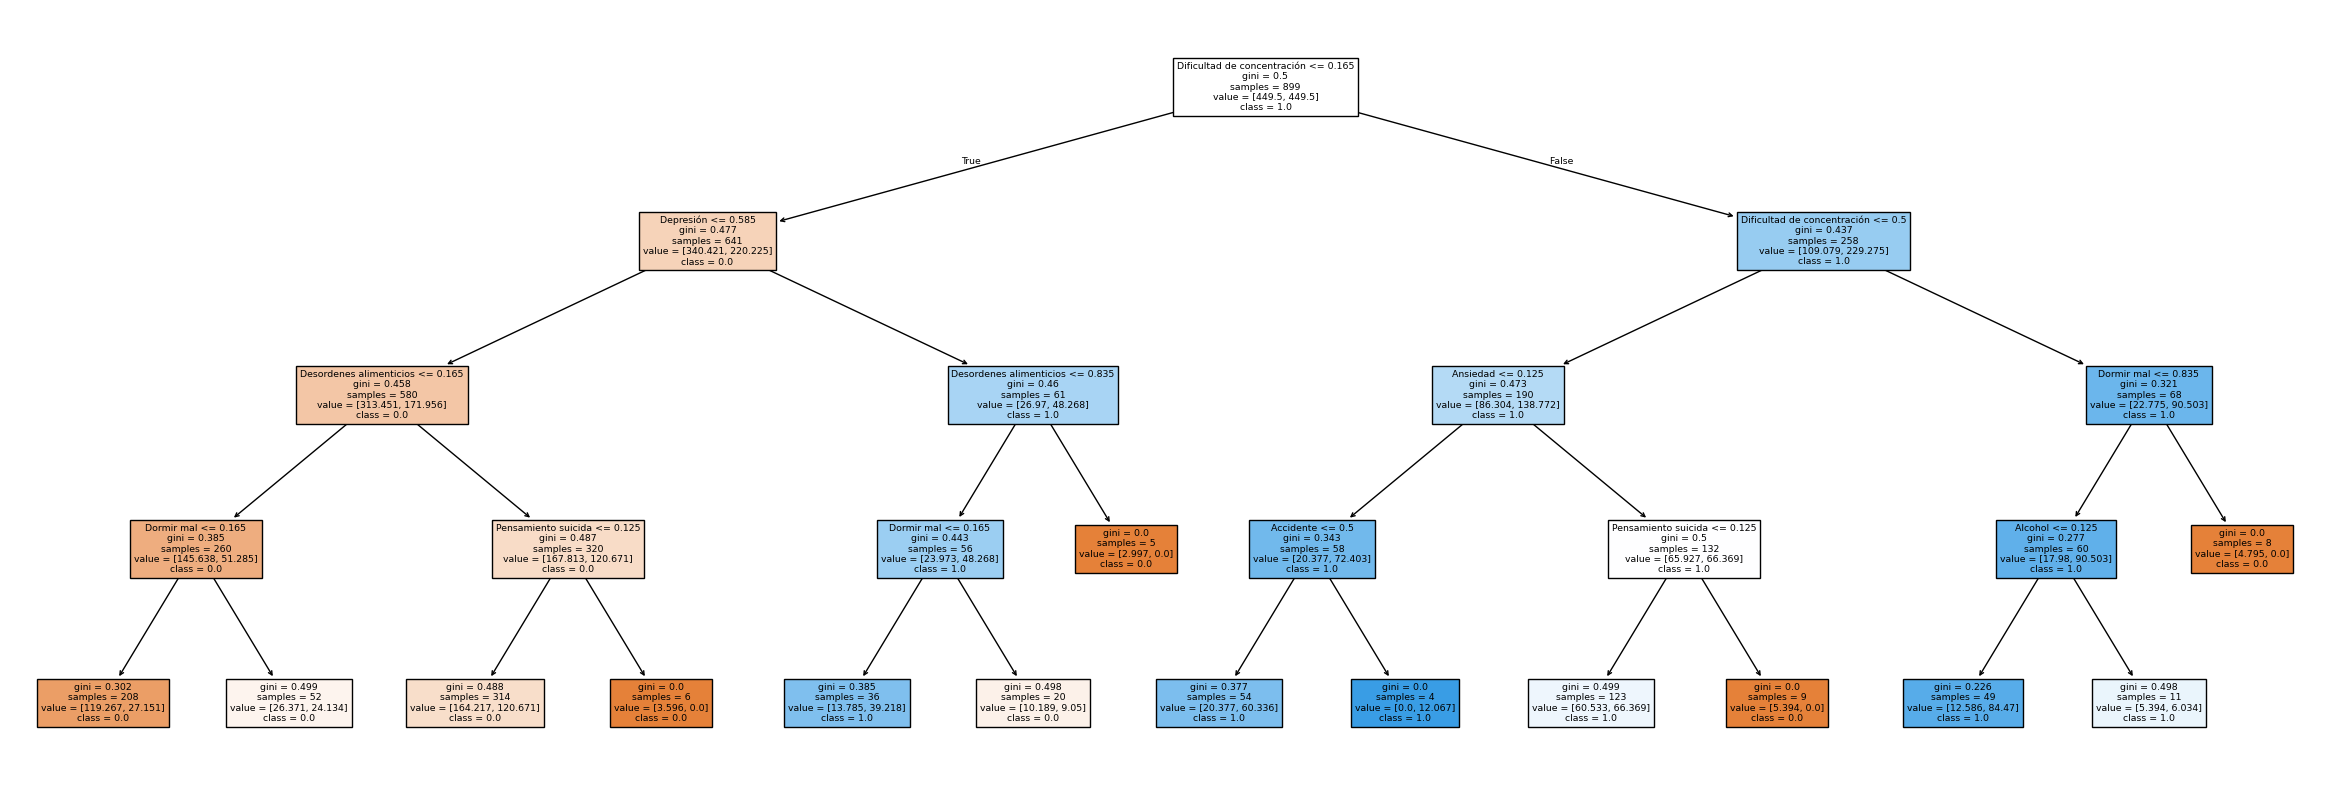

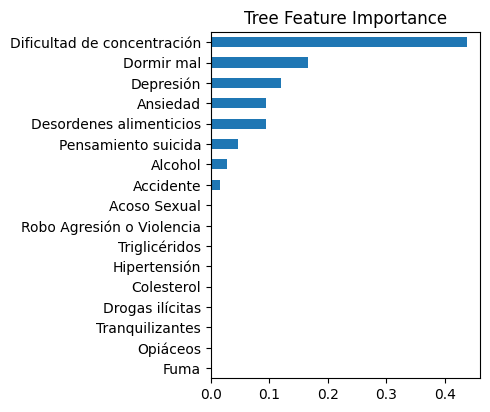

In [194]:
depth = 4
seed = 1

train_test_tree(X_train, X_test, y_train, y_test, depth, seed, feature_names)

In [195]:
neighbours = 3

train_test_knn(X_train, X_test, y_train, y_test, neighbours, feature_names)

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       188
         1.0       0.16      1.00      0.28        37

    accuracy                           0.16       225
   macro avg       0.08      0.50      0.14       225
weighted avg       0.03      0.16      0.05       225

El valor AUC de KNN que optimiza F1 es = 0.5305


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

         0.0       0.90      0.70      0.78       188
         1.0       0.28      0.59      0.38        37

    accuracy                           0.68       225
   macro avg       0.59      0.65      0.58       225
weighted avg       0.80      0.68      0.72       225

El valor AUC de LR que optimiza F1 es = 0.6376


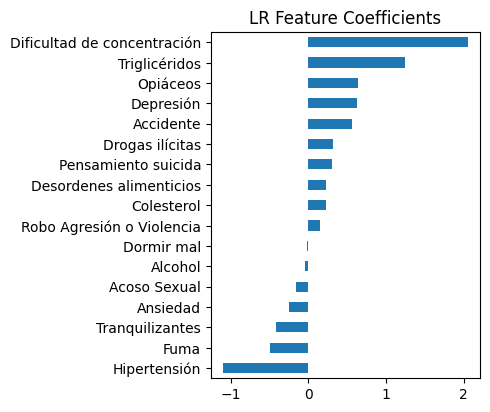

In [196]:
lr_iter = 400
seed = 1

train_test_lr(X_train, X_test, y_train, y_test, lr_iter, seed, feature_names)

              precision    recall  f1-score   support

         0.0       0.89      0.72      0.80       188
         1.0       0.28      0.57      0.38        37

    accuracy                           0.69       225
   macro avg       0.59      0.64      0.59       225
weighted avg       0.79      0.69      0.73       225

El valor AUC de RF que optimiza F1 es = 0.6489


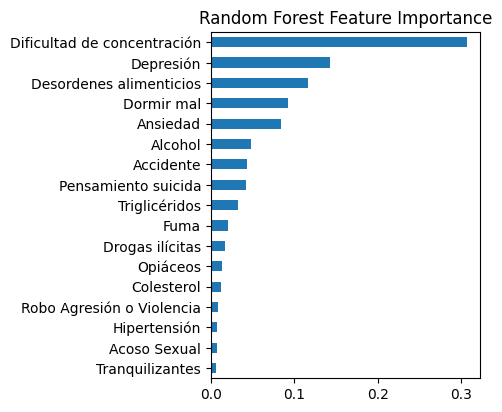

In [197]:
depth = 4
seed = 1
num_estimators = 1000

train_test_rm(X_train, X_test, y_train, y_test, depth, num_estimators, seed, feature_names)

              precision    recall  f1-score   support

         0.0       0.88      0.71      0.78       188
         1.0       0.26      0.51      0.34        37

    accuracy                           0.68       225
   macro avg       0.57      0.61      0.56       225
weighted avg       0.78      0.68      0.71       225

El valor AUC de GBT que optimiza F1 es = 0.6142


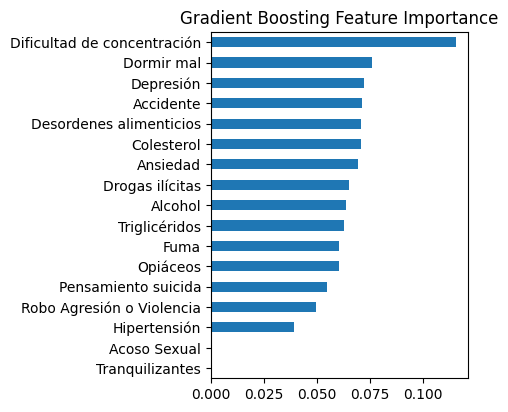

In [198]:
depth = 4
seed = 1
num_estimators = 1000

train_test_gbt(X_train, X_test, y_train, y_test, depth, num_estimators, seed, feature_names)

## Adolescentes Mujeres de 12 a 17 años

Primero vamos a crear las bases de datos que vamos a utilizar. Para CV vamos a utilizar toda la base de datos ya que es validación cruzada. Para el entrenamiento de modelo vamos a utilizar una muestra de 20% para la prueba. Dado que tenemos desbalance de clases, siempre vamos a tratar de mantener la misma proporción de nuestra variable objetivo. Ésto lo logramos utilizando el parametro "stratify=y"

In [199]:
feature_names = df_final_12mas_mujer.columns.drop('Dificultad para aprender')

X = df_final_12mas_mujer[feature_names]

y = df_final_12mas_mujer['Dificultad para aprender']

In [200]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

### Selección de hyperparametros

Dado que vamos a usar árbol de decisión y KNN primero queremos asegurarnos de escoger los hyperparametros correctos. Particularmente la profundidad del arbol y la cantidad de vecinos

Empezando por el arbol, obtamos por una profundidad de 3 dado que esto maximiza AUC mientras que todas las otras métricas de evaluación se mantienen muy similaes

Para los KN Vecinos, en esta muestra Recall y F1 no caen tan rápido y aumentar los vecinos a 7 logra aumentar AUC y hacer el modelo más robusto. Es por eso que se escogió usar 7 vecinos

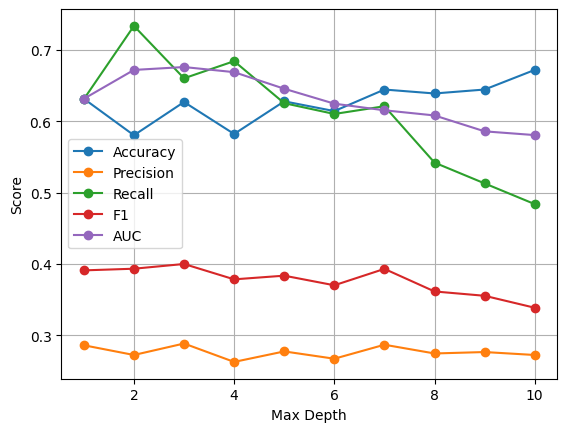

In [201]:
tree_depth(X, y)

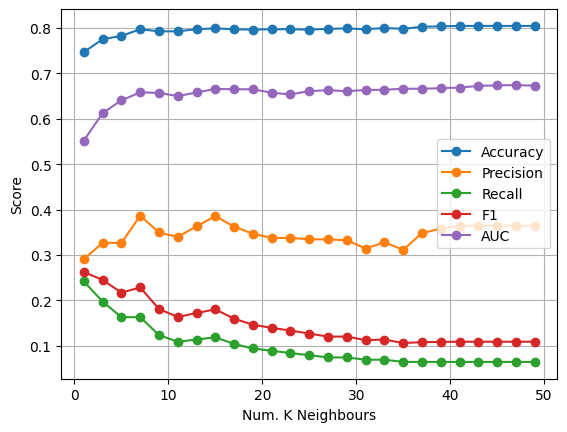

In [202]:
knn_vecinos(X, y)

### Creación de modelos - Validación cruzada

Falta interpretación
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A

In [203]:
depth = 3
neighbours = 7
seed = 1
num_estimators = 1000
lr_iter = 400


cv_todos_los_modelos(X, y, depth, neighbours, seed, num_estimators, lr_iter)

,Decision Tree,KNN,Logistic Regression,Random Forest,XGBoost
Accuracy (CV),0.627812,0.797436,0.701219,0.662691,0.692966
Precision (CV),0.287487,0.386461,0.328704,0.307064,0.317341
Recall (CV),0.655244,0.162683,0.581341,0.645244,0.556585
F1 (CV),0.398197,0.228170,0.418534,0.415395,0.403555
AUC (CV),0.672487,0.658235,0.726080,0.718902,0.683410


In [204]:
depth = 3
neighbours = 7
seed = 1
num_estimators = 1000
lr_iter = 400

cv_todos_los_modelos_smote(X, y, depth, neighbours, seed, num_estimators, lr_iter)

,Decision Tree,KNN,Logistic Regression,Random Forest,XGBoost
Accuracy (CV),0.668179,0.663609,0.691144,0.687432,0.780931
Precision (CV),0.286650,0.284198,0.322390,0.320002,0.356134
Recall (CV),0.517561,0.531829,0.590976,0.611098,0.226341
F1 (CV),0.365369,0.369911,0.416103,0.418926,0.275737
AUC (CV),0.643449,0.652925,0.712858,0.710110,0.670749


### Creación de modelos - Train / Test

Falta interpretación
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A
# A

              precision    recall  f1-score   support

         0.0       0.91      0.60      0.72       178
         1.0       0.30      0.73      0.42        41

    accuracy                           0.63       219
   macro avg       0.60      0.67      0.57       219
weighted avg       0.79      0.63      0.67       219

El valor AUC del árbol que optimiza F1 es = 0.6801


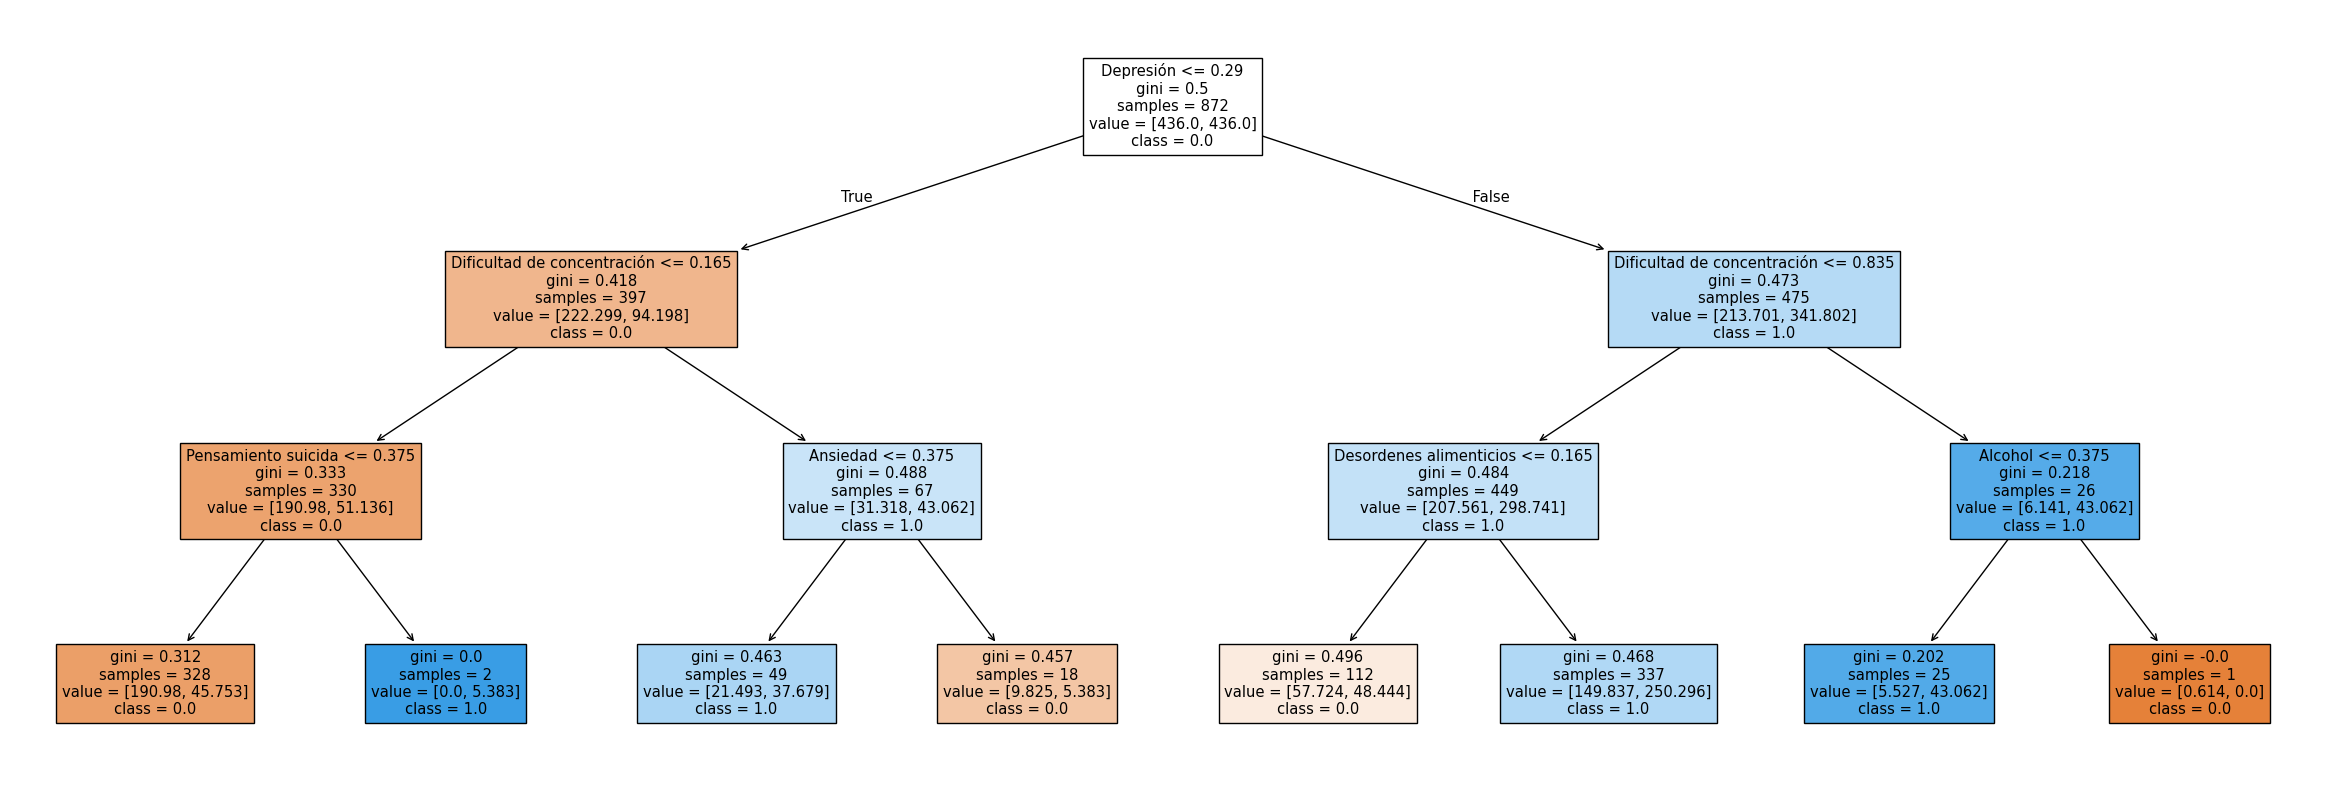

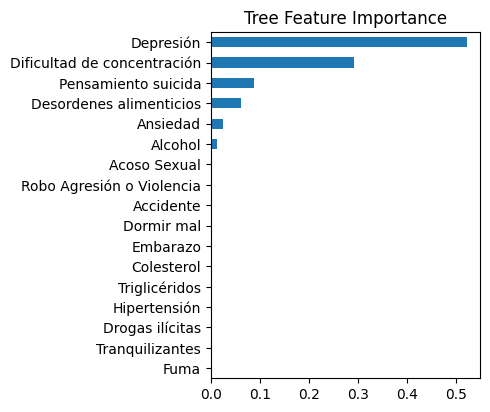

In [205]:
depth = 3
seed = 1

train_test_tree(X_train, X_test, y_train, y_test, depth, seed, feature_names)

In [206]:
neighbours = 7

train_test_knn(X_train, X_test, y_train, y_test, neighbours, feature_names)

              precision    recall  f1-score   support

         0.0       0.91      0.71      0.80       178
         1.0       0.36      0.71      0.48        41

    accuracy                           0.71       219
   macro avg       0.64      0.71      0.64       219
weighted avg       0.81      0.71      0.74       219

El valor AUC de KNN que optimiza F1 es = 0.6829


              precision    recall  f1-score   support

         0.0       0.90      0.71      0.80       178
         1.0       0.35      0.66      0.45        41

    accuracy                           0.70       219
   macro avg       0.62      0.69      0.63       219
weighted avg       0.80      0.70      0.73       219

El valor AUC de LR que optimiza F1 es = 0.7105


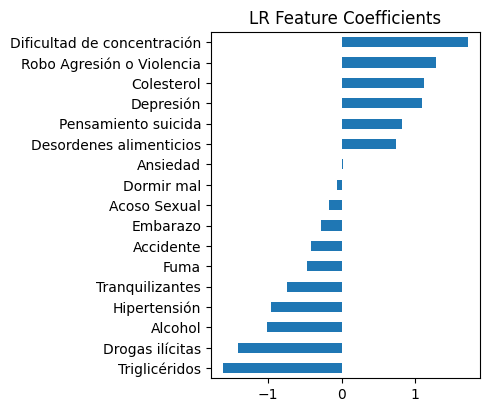

In [207]:
lr_iter = 400
seed = 1

train_test_lr(X_train, X_test, y_train, y_test, lr_iter, seed, feature_names)

              precision    recall  f1-score   support

         0.0       0.87      0.88      0.87       178
         1.0       0.45      0.44      0.44        41

    accuracy                           0.79       219
   macro avg       0.66      0.66      0.66       219
weighted avg       0.79      0.79      0.79       219

El valor AUC de RF que optimiza F1 es = 0.6896


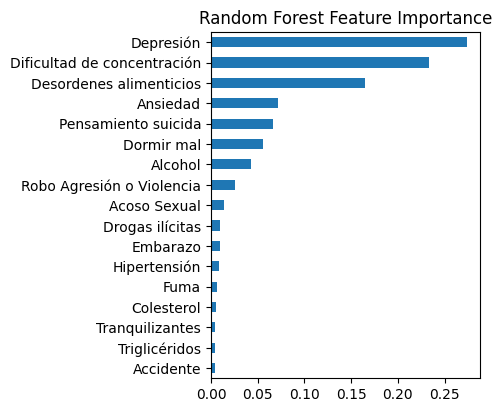

In [208]:
depth = 3
seed = 1
num_estimators = 1000

train_test_rm(X_train, X_test, y_train, y_test, depth, num_estimators, seed, feature_names)

              precision    recall  f1-score   support

         0.0       0.88      0.60      0.71       178
         1.0       0.27      0.66      0.39        41

    accuracy                           0.61       219
   macro avg       0.58      0.63      0.55       219
weighted avg       0.77      0.61      0.65       219

El valor AUC de GBT que optimiza F1 es = 0.6169


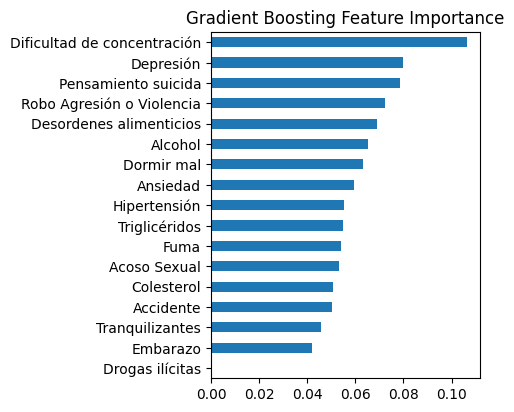

In [209]:
depth = 3
seed = 1
num_estimators = 1000

train_test_gbt(X_train, X_test, y_train, y_test, depth, num_estimators, seed, feature_names)

La IA (ChatGPT y Claude) fue usada particularmente para =
* "Fine-tuning" de los parametros de modelos
* Implementación de StratifiedKFold
* Implementación de SMOTE